In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("C:/Users/DEV/OneDrive/Documents/py excel/sales.csv")
print(df)

              Order ID Customer ID  \
0       CA-2012-124891    RH-19495   
1        IN-2013-77878    JR-16210   
2        IN-2013-71249    CR-12730   
3      ES-2013-1579342    KM-16375   
4         SG-2013-4320     RH-9495   
...                ...         ...   
51285    IN-2014-62366    KE-16420   
51286   US-2014-102288    ZC-21910   
51287   US-2013-155768    LB-16795   
51288   MX-2012-140767    RB-19795   
51289   MX-2012-134460    MC-18100   

                                            Product Name         Category  \
0      Plantronics CS510 - Over-the-Head monaural Wir...       Technology   
1              Novimex Executive Leather Armchair, Black        Furniture   
2                      Nokia Smart Phone, with Caller ID       Technology   
3                         Motorola Smart Phone, Cordless       Technology   
4                         Sharp Wireless Fax, High-Speed       Technology   
...                                                  ...              ...   
5128

In [4]:
df.shape
df.info()
df.describe
df.isnull().sum()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order ID      51290 non-null  str    
 1   Customer ID   51290 non-null  str    
 2   Product Name  51290 non-null  str    
 3   Category      51290 non-null  str    
 4   Quantity      51290 non-null  int64  
 5   Sales         51290 non-null  float64
 6   Profit        51290 non-null  float64
 7   Order Date    51290 non-null  str    
 8   Region        51290 non-null  str    
 9   State         51290 non-null  str    
dtypes: float64(2), int64(1), str(7)
memory usage: 3.9 MB


Index(['Order ID', 'Customer ID', 'Product Name', 'Category', 'Quantity',
       'Sales', 'Profit', 'Order Date', 'Region', 'State'],
      dtype='str')

In [5]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)
df.to_csv("amazon_cleaned.csv", index=False)

Dataset Shape: (51290, 10)

Missing Values:
Order ID        0
Customer ID     0
Product Name    0
Category        0
Quantity        0
Sales           0
Profit          0
Order Date      0
Region          0
State           0
dtype: int64

Duplicate Rows: 9


In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

print(df['Order Date'].dtype)


datetime64[us]


In [7]:
print("\nSummary Statistics:")
print(df.describe())

print("\nTotal Sales:", df['Sales'].sum())
print("Total Profit:", df['Profit'].sum())
print("Total Quantity Sold:", df['Quantity'].sum())
print("Total Orders:", df['Order ID'].nunique())



Summary Statistics:
           Quantity         Sales        Profit                  Order Date
count  51281.000000  51281.000000  51281.000000                       31218
mean       3.476726    246.505028     28.612904  2013-05-17 15:40:09.917355
min        1.000000      0.444000  -6599.978000         2011-01-13 00:00:00
25%        2.000000     30.766500      0.000000         2012-06-22 06:00:00
50%        3.000000     85.056000      9.240000         2013-07-19 00:00:00
75%        5.000000    251.010000     36.810000         2014-05-23 00:00:00
max       14.000000  22638.480000   8399.976000         2014-12-31 00:00:00
std        2.278873    487.600002    174.355838                         NaN

Total Sales: 12641024.34188
Total Profit: 1467298.3340799997
Total Quantity Sold: 178290
Total Orders: 25035


Top 10 Products by Sales

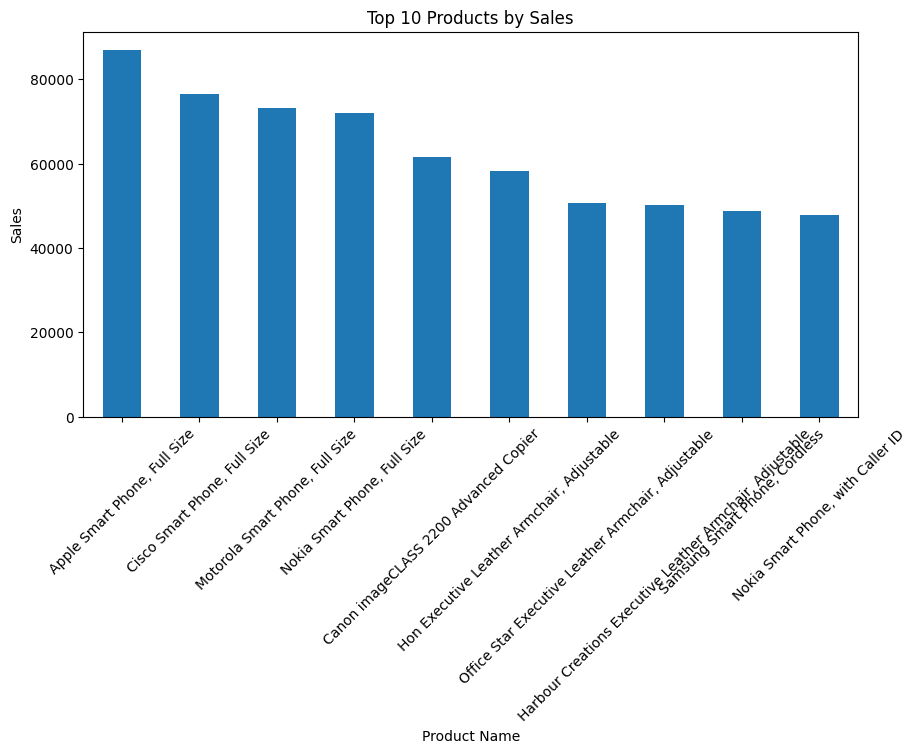

In [8]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title('Top 10 Products by Sales')
plt.xlabel('Product Name')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

Sales by Category

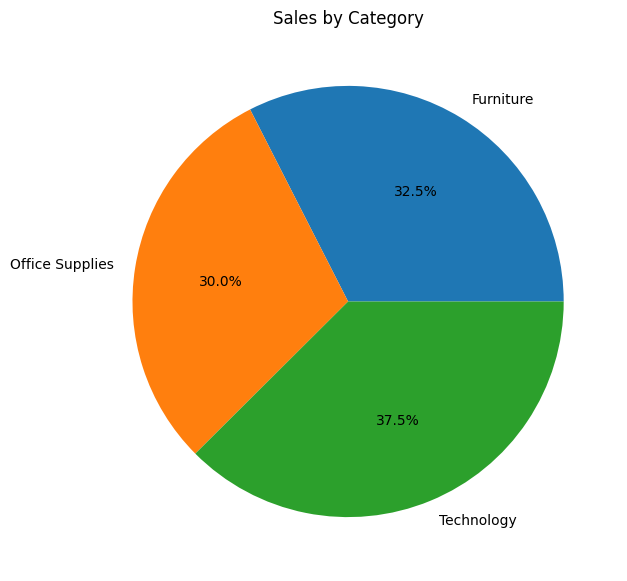

In [9]:

category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(7,7))
plt.pie(category_sales,
        labels=category_sales.index,
        autopct='%1.1f%%')
plt.title('Sales by Category')
plt.show()

 Profit by Category

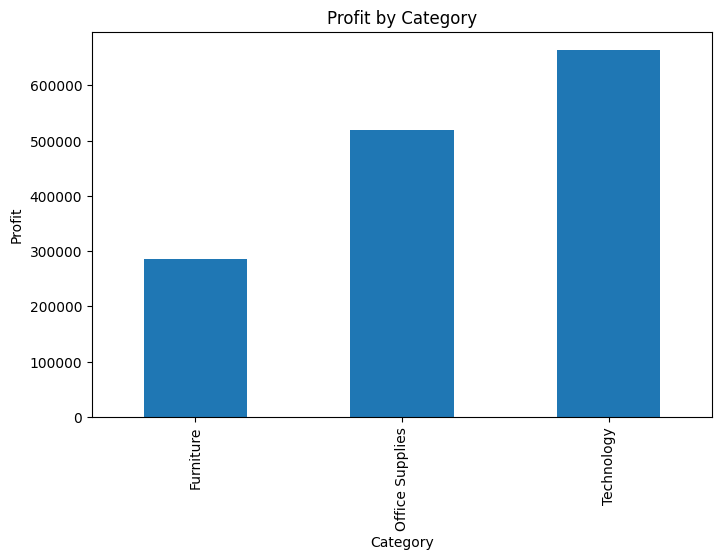

In [10]:

category_profit = df.groupby('Category')['Profit'].sum()

plt.figure(figsize=(8,5))
category_profit.plot(kind='bar')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()



Sales by Region

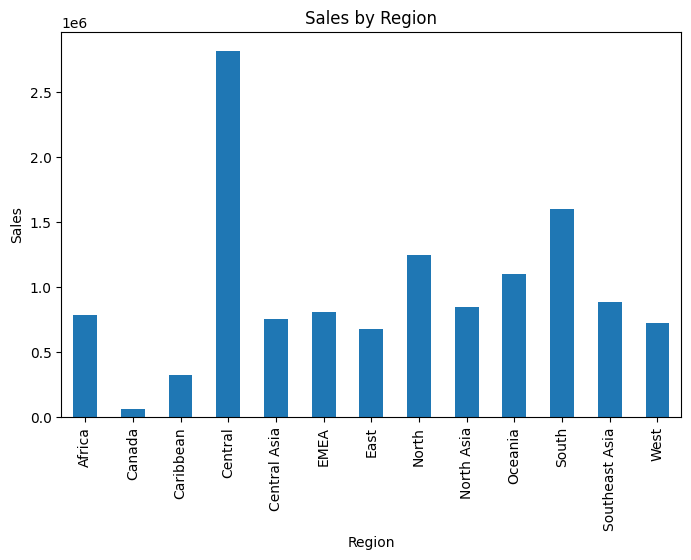

In [11]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

 Profit by Region

Text(0, 0.5, 'Pro')

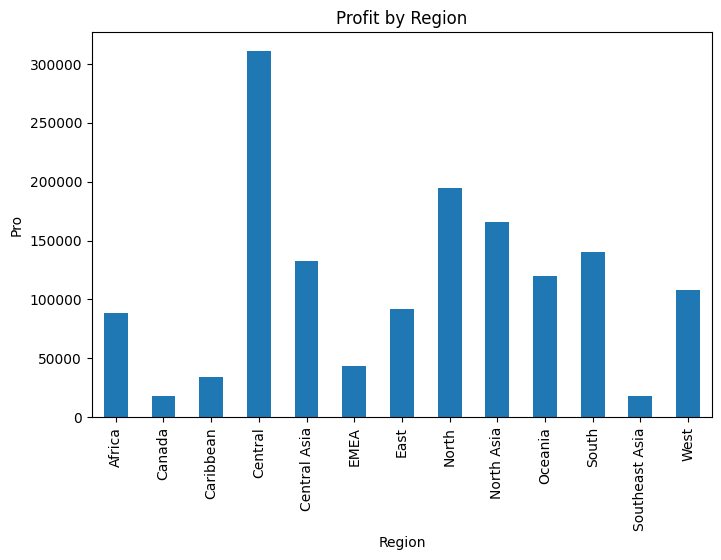

In [12]:
region_profit = df.groupby('Region')['Profit'].sum()

plt.figure(figsize=(8,5))
region_profit.plot(kind='bar')
plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Pro')

Monthly Sales Trend

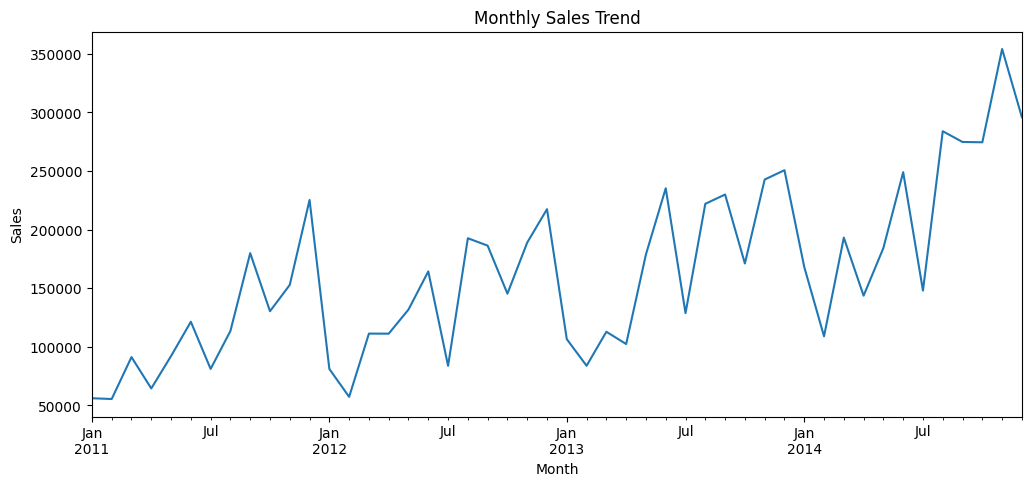

In [13]:

df['Month'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

Monthly Profit Trend

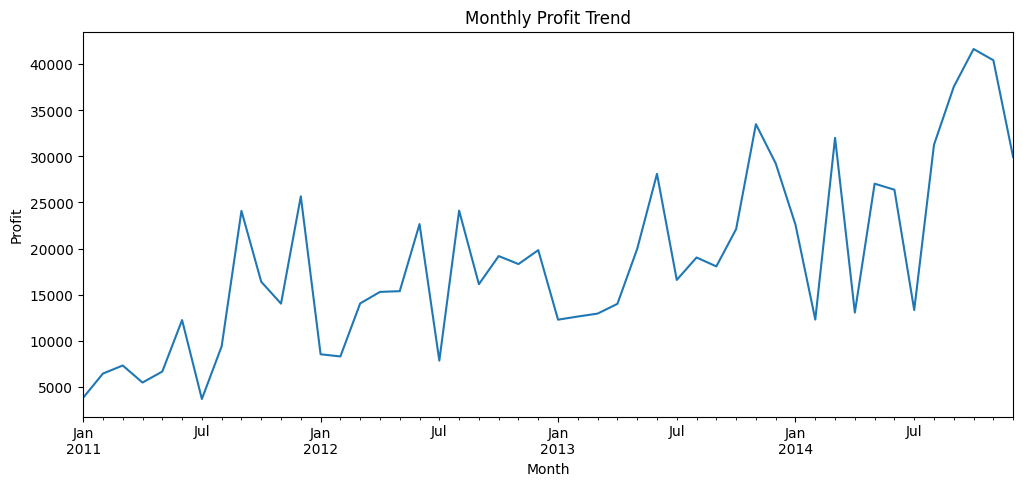

In [14]:
monthly_profit = df.groupby('Month')['Profit'].sum()

plt.figure(figsize=(12,5))
monthly_profit.plot()
plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.show()


Sales vs Profit

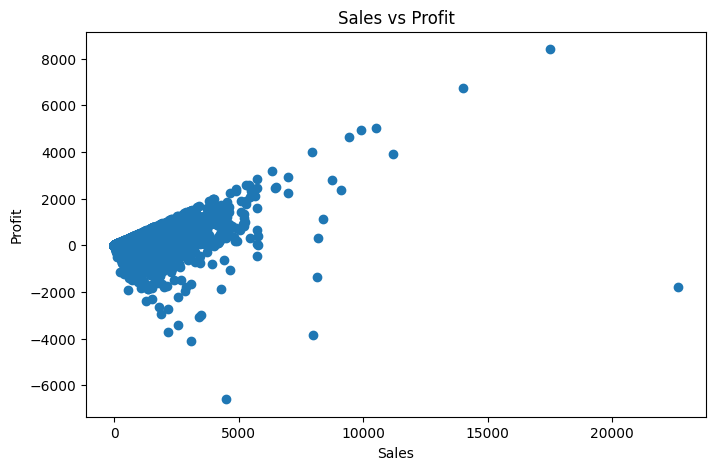

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(df['Sales'], df['Profit'])
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

 Quantity Distribution

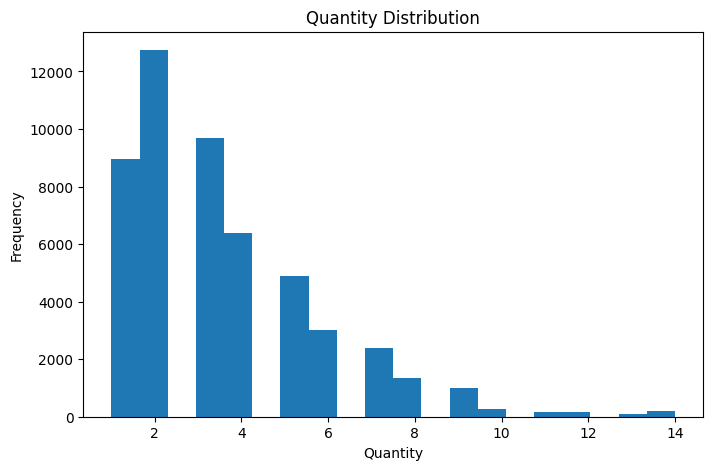

In [16]:
plt.figure(figsize=(8,5))
plt.hist(df['Quantity'], bins=20)
plt.title('Quantity Distribution')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

Top 10 States by Sales

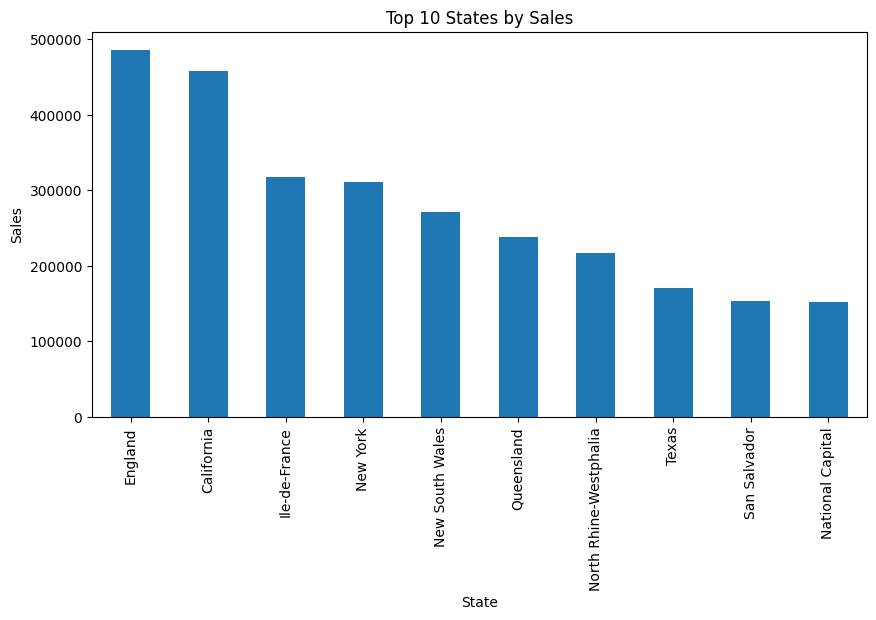

In [17]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar')
plt.title('Top 10 States by Sales')
plt.xlabel('State')
plt.ylabel('Sales')
plt.show()


Business Insights

In [18]:
print("\n----- Business Insights -----")
print("Top Product by Sales:")
print(df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(1))

print("\nMost Profitable Category:")
print(df.groupby('Category')['Profit'].sum().sort_values(ascending=False).head(1))

print("\nBest Sales Region:")
print(df.groupby('Region')['Sales'].sum().sort_values(ascending=False).head(1))

print("\nBest Profit Region:")
print(df.groupby('Region')['Profit'].sum().sort_values(ascending=False).head(1))


----- Business Insights -----
Top Product by Sales:
Product Name
Apple Smart Phone, Full Size    86935.7786
Name: Sales, dtype: float64

Most Profitable Category:
Category
Technology    663767.99318
Name: Profit, dtype: float64

Best Sales Region:
Region
Central    2.822265e+06
Name: Sales, dtype: float64

Best Profit Region:
Region
Central    311393.63164
Name: Profit, dtype: float64
